# 09 - Customer Segmentation

## Customer Intelligence Platform

---
This notebook segments customers using K-Means clustering, creating business-meaningful groups for targeted strategies.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd, numpy as np, matplotlib.pyplot as plt, joblib, shap
%matplotlib inline

from src.load_data import load_features
from src.config import TARGET
# from src.segment import (
#     prepare_segmentation_features,
#     find_optimal_clusters,
#     plot_elbow_silhouette,
#     fit_kmeans,
#     assign_segment_names,
#     segment_profiles,
#     plot_segment_radar,
# )
from src.segment import *

In [2]:
# load feature enriched dataset
df = load_features()

✅ Loaded features: 7,043 rows × 35 cols


## Prepare Segmentation Features

---

In [3]:
X_scaled, scaler, feature_names = prepare_segmentation_features(df)
print(f"Segmentation features: {feature_names}")
print(f"Scaled shape: {X_scaled.shape}")

Segmentation features: ['Tenure Months', 'Monthly Charges', 'Total Charges', 'service_count']
Scaled shape: (7043, 4)


## Optimal Cluster Selection

---

Optimal number of clusters: 2


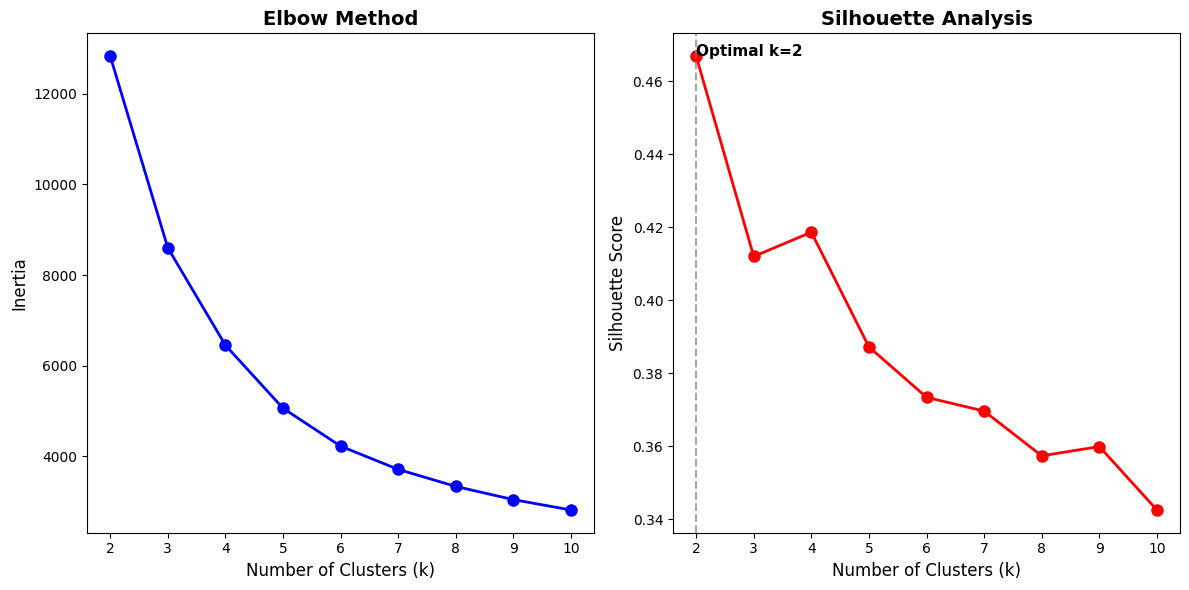

In [4]:
k_range = range(2, 11)
inertias, sil_scores, optimal_k = find_optimal_clusters(X_scaled, k_range)
print(f"Optimal number of clusters: {optimal_k}")

fig = plot_elbow_silhouette(k_range, inertias, sil_scores, optimal_k)
plt.show()

## Fit K-Means

---

In [5]:
km, labels = fit_kmeans(X_scaled, n_clusters=5)
df["cluster"] = labels

[INFO] K-Means (k=5): Silhouette Score = 0.3873


## Assign Segment Names

---

In [6]:
df = assign_segment_names(df, labels, feature_names)
print(f"\nSegment Distribution:")
print(df["segment"].value_counts())

[INFO] Segments assigned: {'Low Value': 1956, 'Growth Potential': 1532, 'VIP At Risk': 1451, 'VIP Loyal': 1193, 'New Customers': 911}

Segment Distribution:
segment
Low Value           1956
Growth Potential    1532
VIP At Risk         1451
VIP Loyal           1193
New Customers        911
Name: count, dtype: int64


## Segment Profiles

---

In [7]:
profiles = segment_profiles(df)
profiles

,Tenure Months_mean,Tenure Months_median,Monthly Charges_mean,Monthly Charges_median,Total Charges_mean,Total Charges_sum,service_count_mean,customer_count
segment,,,,,,,,
Growth Potential,10.007833,7.0,29.770986,21.25,279.670039,428454.50,1.255222,1532
Low Value,11.268916,9.0,76.959254,76.05,850.956621,1664471.15,3.097648,1956
New Customers,53.515917,53.0,27.909276,24.25,1467.868057,1337227.80,1.608123,911
VIP At Risk,44.646451,43.0,80.799966,81.15,3494.449070,5070445.60,4.580979,1451
VIP Loyal,64.611065,67.0,98.331140,101.05,6333.252012,7555569.65,6.362951,1193


## Segment Visualization

---

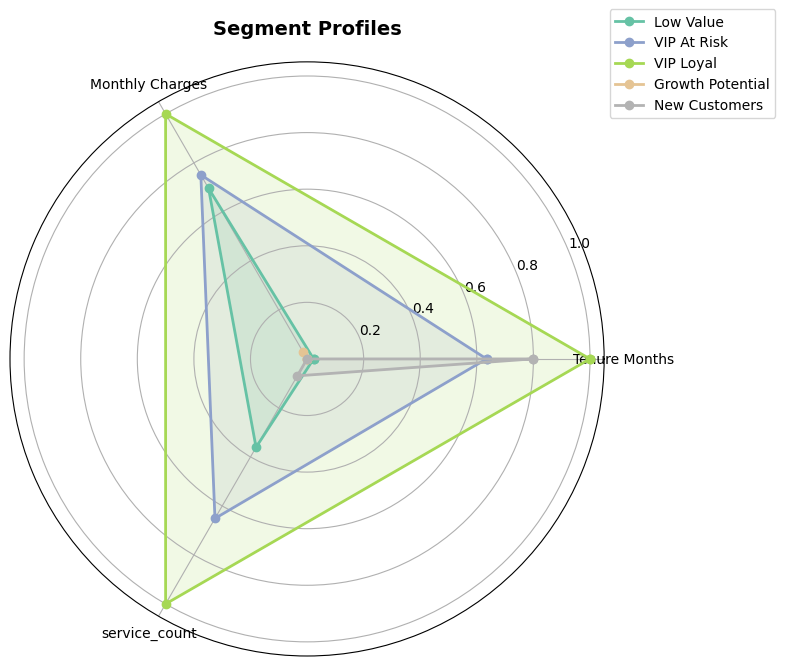

In [8]:
fig = plot_segment_radar(df)
plt.show()

In [9]:
# Churn rate by segment
seg_churn = df.groupby("segment")[TARGET].agg(["mean", "count"]).round(4)
seg_churn.columns = ["Churn Rate", "Customer Count"]
seg_churn = seg_churn.sort_values("Churn Rate", ascending=False)
seg_churn

,Churn Rate,Customer Count
segment,,
Low Value,0.5061,1956
Growth Potential,0.2435,1532
VIP At Risk,0.2109,1451
VIP Loyal,0.1333,1193
New Customers,0.0450,911


## Summary

---
### Final Customer Segments

| Segment | Description | Strategy |
|---------|-------------|----------|
| VIP Loyal | High value, long tenure, low churn risk | Loyalty rewards, upsell |
| VIP At Risk | High value but elevated churn risk | Premium retention package |
| New Customers | Recently joined, uncertain loyalty | Strong onboarding program |
| Low Value | Low spend, low engagement | Standard monitoring |
| Growth Potential | Moderate value, growth opportunity | Service expansion offers |
